
# Bank of England Individual Capstone Project  
## Sentiment in Central Bank Speeches and UK Economic Conditions

**Student:** Afshar Sanam  
**Programme:** LSE PGCert Data Analytics  
**Academic Supervisor:** James Abdey  

---

### Approved Research Question
**How does sentiment in Bank of England speeches evolve over time, and how does it relate descriptively to key UK macroeconomic indicators and market conditions, such as the FTSE 250 index, during both benign and turbulent economic periods?**

This project is intentionally **exploratory and descriptive**. Predictive modelling and causal inference are explicitly out of scope, in line with supervisor guidance.



## Research Design & Scope
- Exploratory, descriptive analysis
- Primary sentiment method: LSE sentiment-labelled wordlist
- Narrative and visual storytelling emphasis
- Correlation interpreted descriptively



## Data Sources
- Bank of England speech corpus
- LSE sentiment-labelled wordlist
- UK macroeconomic indicators (CPI / CPIH)
- Market indicators: FTSE 250 (primary), FTSE 100 (secondary)



## Methodology Overview
Dictionary-based sentiment scoring aggregated monthly/quarterly.
Time-series visualisation and descriptive correlation analysis.
No predictive modelling or causal inference.



## Economic Regime Framing
**Benign periods:** stable inflation, steady growth  
**Turbulent periods:** Brexit, Covid-19, inflation surge


In [1]:
# =========================
# 0) Imports + setup
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter
from datetime import datetime


In [2]:
# NLP utilities (as in your starter code)
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('words')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sanama\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sanama\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\sanama\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\sanama\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [3]:
# OPTIONAL: nicer plots
plt.rcParams["figure.figsize"] = (12, 6)

In [4]:
# =========================
# 1) Load speeches dataset
# =========================

SPEECHES_PATH = r"C:\Users\sanama\OneDrive - Autodesk\LSE_ICP_BOE\all_speeches.csv"
df = pd.read_csv(SPEECHES_PATH)

# Quick checks
print(df.shape)
print(df.columns)
display(df.head())


(7721, 7)
Index(['reference', 'country', 'date', 'title', 'author', 'is_gov', 'text'], dtype='object')


,reference,country,date,title,author,is_gov,text
0,r901128a_BOA,australia,1990-11-28,A Proper Role for Monetary Policy,fraser,0,They would no doubt argue that to have two obj...
1,r911003a_BOA,australia,1991-10-03,,fraser,0,Today I wish to talk about real interest rates...
2,r920314a_BOA,australia,1992-03-14,,fraser,0,I welcome this opportunity to talk about prosp...
3,r920529a_BOA,australia,1992-05-29,,fraser,0,It is a pleasure to have this opportunity to a...
4,r920817a_BOA,australia,1992-08-17,,fraser,0,"As a long-time fan of Don Sanders, I am deligh..."


In [5]:
# Make sure these columns exist in your Kaggle/BoE subset
required_cols = {"country", "date", "text"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns in speeches file: {missing}. Found: {df.columns.tolist()}")


In [6]:
# Parse date
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Basic metadata checks
print(df["country"].value_counts().head(20))
print("Date range:", df["date"].min(), "to", df["date"].max())

country
euro area         2351
united states     1551
united kingdom    1209
japan              755
canada             620
sweden             600
switzerland        351
australia          284
Name: count, dtype: int64
Date range: 1900-01-01 00:00:00 to 2022-11-10 00:00:00


In [7]:
# =========================
# 2) Clean text (IMPORTANT: do this BEFORE subsetting)
# =========================

# If there are NaNs, ensure string
df["text"] = df["text"].astype(str)

# Lowercase
df["text_clean"] = df["text"].str.lower()

# Remove punctuation (keep letters/numbers/spaces)
df["text_clean"] = df["text_clean"].str.replace(r"[^\w\s]", " ", regex=True)

# Collapse multiple spaces
df["text_clean"] = df["text_clean"].str.replace(r"\s+", " ", regex=True).str.strip()

# Length feature (optional)
df["len"] = df["text_clean"].str.len()

display(df[["date", "country", "len", "text_clean"]].head())

,date,country,len,text_clean
0,1990-11-28,australia,20827,they would no doubt argue that to have two obj...
1,1991-10-03,australia,18476,today i wish to talk about real interest rates...
2,1992-03-14,australia,20725,i welcome this opportunity to talk about prosp...
3,1992-05-29,australia,23188,it is a pleasure to have this opportunity to a...
4,1992-08-17,australia,24834,as a long time fan of don sanders i am delight...


In [8]:
# =========================
# 3) Subset to UK (Bank of England speeches)
# =========================

# Note: Kaggle uses "united kingdom" (lowercase) in your starter checks
dfi = (
    df[df["country"].str.lower().eq("united kingdom")]
    .sort_values("date")
    .reset_index(drop=True)
)

print("UK subset:", dfi.shape)
display(dfi.head())

UK subset: (1209, 9)


,reference,country,date,title,author,is_gov,text,text_clean,len
0,r980915a_BOE,united kingdom,1998-09-15,Speech,george,0,"Thank you, Chairman. I'm actually very pleased...",thank you chairman i m actually very pleased t...,13415
1,r981021b_BOE,united kingdom,1998-10-21,Britain in Europe,george,0,It's a great pleasure to be here in the beauti...,it s a great pleasure to be here in the beauti...,23787
2,r981021a_BOE,united kingdom,1998-10-21,Impact of the recent turbulence in internation...,king,1,Few industries have suffered more from volatil...,few industries have suffered more from volatil...,13418
3,r981101a_BOE,united kingdom,1998-11-01,"Economic policy, with and without forecasts",budd,0,My topic this evening is the use of forecasts ...,my topic this evening is the use of forecasts ...,27139
4,r981101b_BOE,united kingdom,1998-11-01,Inflation targeting in practice: the UK experi...,vickers,0,"Six years ago this week, sterling left the exc...",six years ago this week sterling left the exch...,27072


In [9]:
# =========================
# 4) Load LSE lexicon + score (PRIMARY sentiment method)
# =========================

LEXICON_PATH = r"C:\Users\sanama\OneDrive - Autodesk\LSE_ICP_BOE\LSE_DA_BoE_Employer_project_Sentiment-labelled_wordlist.xlsx"
lexicon = pd.read_excel(LEXICON_PATH)

# Clean column names
lexicon.columns = [c.strip() for c in lexicon.columns]

# EXPECTED columns (from your PDF)
expected = {"Word","Negative","Positive","Uncertainty","Litigious","Strong","Weak"}
missing = expected - set(lexicon.columns)
if missing:
    raise ValueError(
        f"Lexicon columns don't match expected set.\n"
        f"Missing: {missing}\n"
        f"Found: {lexicon.columns.tolist()}"
    )

# Normalize the Word column
lexicon["Word"] = lexicon["Word"].astype(str).str.lower().str.strip()

# Ensure label columns are numeric 0/1
for col in ["Negative","Positive","Uncertainty","Litigious","Strong","Weak"]:
    lexicon[col] = pd.to_numeric(lexicon[col], errors="coerce").fillna(0).astype(int)

# Dictionaries
neg_dict  = dict(zip(lexicon["Word"], lexicon["Negative"]))
pos_dict  = dict(zip(lexicon["Word"], lexicon["Positive"]))
unc_dict  = dict(zip(lexicon["Word"], lexicon["Uncertainty"]))
lit_dict  = dict(zip(lexicon["Word"], lexicon["Litigious"]))
str_dict  = dict(zip(lexicon["Word"], lexicon["Strong"]))
weak_dict = dict(zip(lexicon["Word"], lexicon["Weak"]))

def score_lse_lexicon(text: str) -> pd.Series:
    """
    Returns counts for each LSE category + tone index.
    tone = (pos - neg) / (pos + neg + 1)
    """
    if pd.isna(text):
        return pd.Series({
            "lse_pos": 0, "lse_neg": 0, "lse_unc": 0, "lse_lit": 0, "lse_str": 0, "lse_weak": 0,
            "lse_tone": 0.0
        })

    tokens = re.findall(r"[a-z]+", str(text).lower())
    counts = Counter(tokens)

    pos = sum(counts[w] * pos_dict.get(w, 0) for w in counts)
    neg = sum(counts[w] * neg_dict.get(w, 0) for w in counts)
    unc = sum(counts[w] * unc_dict.get(w, 0) for w in counts)
    lit = sum(counts[w] * lit_dict.get(w, 0) for w in counts)
    strong = sum(counts[w] * str_dict.get(w, 0) for w in counts)
    weak = sum(counts[w] * weak_dict.get(w, 0) for w in counts)

    tone = (pos - neg) / (pos + neg + 1)

    return pd.Series({
        "lse_pos": pos, "lse_neg": neg, "lse_unc": unc, "lse_lit": lit, "lse_str": strong, "lse_weak": weak,
        "lse_tone": tone
    })

# Apply scoring to UK subset (USE text_clean)
dfi = dfi.copy()
dfi = pd.concat([dfi, dfi["text_clean"].apply(score_lse_lexicon)], axis=1)

display(dfi[["date","lse_pos","lse_neg","lse_unc","lse_tone"]].head())

,date,lse_pos,lse_neg,lse_unc,lse_tone
0,1998-09-15,39.0,63.0,24.0,-0.233010
1,1998-10-21,82.0,87.0,52.0,-0.029412
2,1998-10-21,33.0,61.0,49.0,-0.294737
3,1998-11-01,43.0,78.0,92.0,-0.286885
4,1998-11-01,46.0,102.0,119.0,-0.375839


In [10]:
# =========================
# 5) VADER sentiment (COMPARISON — optional)
# =========================

sia = SentimentIntensityAnalyzer()

def vader_scores(text: str) -> pd.Series:
    score = sia.polarity_scores(str(text))
    return pd.Series({
        "vader_neg": score["neg"],
        "vader_neu": score["neu"],
        "vader_pos": score["pos"],
        "vader_compound": score["compound"],
    })

dfi = pd.concat([dfi, dfi["text_clean"].apply(vader_scores)], axis=1)
display(dfi[["vader_neg","vader_neu","vader_pos","vader_compound"]].head())


,vader_neg,vader_neu,vader_pos,vader_compound
0,0.081,0.822,0.097,0.9959
1,0.067,0.778,0.155,0.9999
2,0.078,0.806,0.116,0.9984
3,0.052,0.858,0.090,0.9996
4,0.068,0.841,0.092,0.9991


In [11]:
# =========================
# 6) TextBlob sentiment (COMPARISON — optional)
# =========================

def textblob_scores(text: str) -> pd.Series:
    s = TextBlob(str(text)).sentiment
    return pd.Series({"tb_polarity": s.polarity, "tb_subjectivity": s.subjectivity})

dfi = pd.concat([dfi, dfi["text_clean"].apply(textblob_scores)], axis=1)
display(dfi[["tb_polarity","tb_subjectivity"]].head())

,tb_polarity,tb_subjectivity
0,0.081964,0.427775
1,0.078777,0.361576
2,0.088670,0.395059
3,0.087412,0.476088
4,0.057692,0.391171


In [12]:
# =========================
# 7) Time aggregation (monthly + quarterly) — needed for report visuals
# =========================

# Create month/quarter buckets
dfi["month"] = dfi["date"].dt.to_period("M").dt.to_timestamp()
dfi["quarter"] = dfi["date"].dt.to_period("Q").dt.to_timestamp()

monthly = dfi.groupby("month", as_index=False).agg(
    lse_tone_mean=("lse_tone", "mean"),
    lse_pos_sum=("lse_pos", "sum"),
    lse_neg_sum=("lse_neg", "sum"),
    lse_unc_sum=("lse_unc", "sum"),
    vader_compound_mean=("vader_compound", "mean"),
    tb_polarity_mean=("tb_polarity", "mean"),
    speech_count=("text_clean", "size"),
)

quarterly = dfi.groupby("quarter", as_index=False).agg(
    lse_tone_mean=("lse_tone", "mean"),
    vader_compound_mean=("vader_compound", "mean"),
    tb_polarity_mean=("tb_polarity", "mean"),
    speech_count=("text_clean", "size"),
)

display(monthly.head())
display(quarterly.head())

,month,lse_tone_mean,lse_pos_sum,lse_neg_sum,lse_unc_sum,vader_compound_mean,tb_polarity_mean,speech_count
0,1998-09-01,-0.233010,39.0,63.0,24.0,0.99590,0.081964,1
1,1998-10-01,-0.162074,115.0,148.0,101.0,0.99915,0.083723,2
2,1998-11-01,-0.312651,128.0,249.0,238.0,0.99690,0.080969,3
3,1998-12-01,-0.340806,143.0,296.0,142.0,0.99920,0.075721,2
4,1999-01-01,-0.280357,87.0,157.0,60.0,0.99790,0.086172,2


,quarter,lse_tone_mean,vader_compound_mean,tb_polarity_mean,speech_count
0,1998-07-01,-0.233010,0.995900,0.081964,1
1,1998-10-01,-0.277673,0.998200,0.080257,7
2,1999-01-01,-0.097256,0.999125,0.090505,8
3,1999-04-01,0.071934,0.999637,0.099832,8
4,1999-07-01,-0.386020,0.599800,0.067215,5


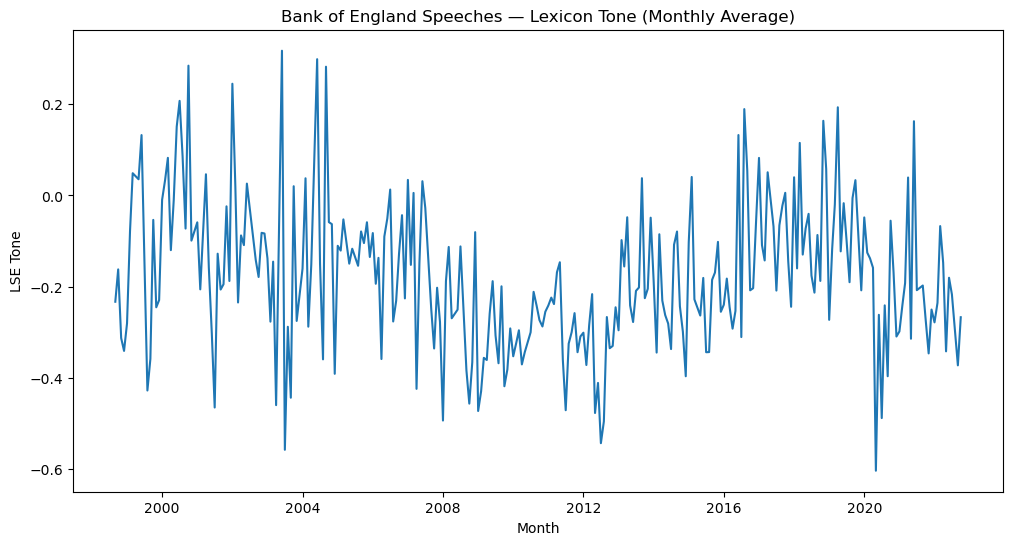

In [13]:
# =========================
# 8) Core plots (for storytelling)
# =========================

# Plot LSE tone over time (monthly)
plt.figure()
plt.plot(monthly["month"], monthly["lse_tone_mean"])
plt.title("Bank of England Speeches — Lexicon Tone (Monthly Average)")
plt.xlabel("Month")
plt.ylabel("LSE Tone")
plt.show()


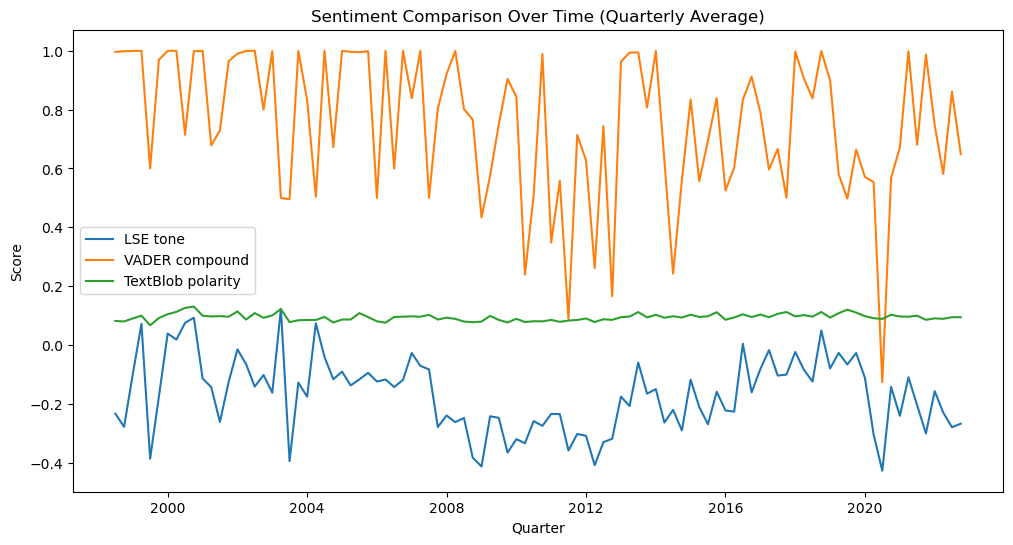

In [14]:
# Compare LSE vs VADER vs TextBlob (quarterly)
plt.figure()
plt.plot(quarterly["quarter"], quarterly["lse_tone_mean"], label="LSE tone")
plt.plot(quarterly["quarter"], quarterly["vader_compound_mean"], label="VADER compound")
plt.plot(quarterly["quarter"], quarterly["tb_polarity_mean"], label="TextBlob polarity")
plt.title("Sentiment Comparison Over Time (Quarterly Average)")
plt.xlabel("Quarter")
plt.ylabel("Score")
plt.legend()
plt.show()

[('economy', 26), ('inflation', 22), ('growth', 15), ('policy', 13), ('demand', 13), ('employment', 10), ('whole', 9), ('sectors', 9), ('know', 8), ('capacity', 8), ('monetary', 7), ('interest', 7), ('rates', 7), ('economic', 7), ('rate', 7), ('could', 7), ('target', 7), ('evidence', 7), ('exposed', 7), ('even', 6)]


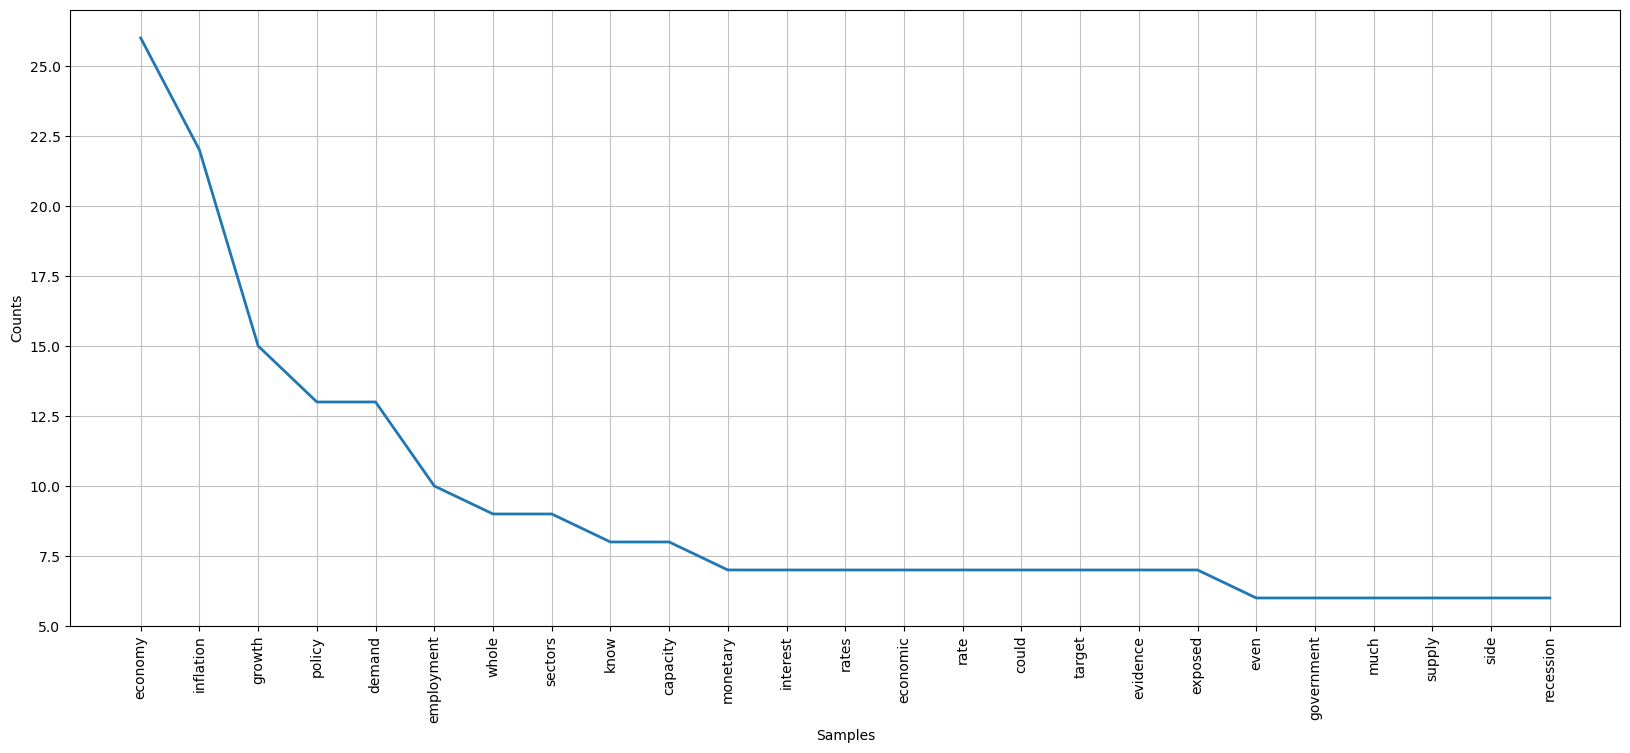

In [15]:
# =========================
# 9) Frequency distribution (single speech demo, cleaned + robust)
# =========================

# Choose which speech index to inspect
i = 0
tokens = word_tokenize(dfi.loc[i, "text_clean"])

filtered_text = [
    w.lower() for w in tokens
    if w.isalpha() and w.lower() not in stop_words
]

freq_dist = FreqDist(filtered_text)
print(freq_dist.most_common(20))

fig, ax = plt.subplots(dpi=100)
fig.set_size_inches(20, 8)
freq_dist.plot(25, cumulative=False)
plt.show()

In [16]:
# =========================
# 10) FTSE 250 analysis (monthly, descriptive)
# =========================

# Load FTSE 250 data
ftse = pd.read_csv(
    r"C:\Users\sanama\OneDrive - Autodesk\LSE_ICP_BOE\FTSE_250_1995_2025.csv"
)

# Standardise column names defensively
ftse.columns = [c.strip().lower() for c in ftse.columns]

# Expected columns check (based on PDF / CSV)
required_cols = {"date", "close"}
missing = required_cols - set(ftse.columns)
if missing:
    raise ValueError(f"Missing expected FTSE columns: {missing}")

# Parse date
ftse["date"] = pd.to_datetime(ftse["date"], errors="coerce")
ftse = ftse.dropna(subset=["date"])

# Create monthly timestamp
ftse["month"] = ftse["date"].dt.to_period("M").dt.to_timestamp()

# Aggregate to monthly mean close
ftse_monthly = (
    ftse
    .groupby("month", as_index=False)["close"]
    .mean()
    .rename(columns={"close": "ftse250_mean_close"})
)

ftse_monthly.head()


,month,ftse250_mean_close
0,1995-01-01,3442.438095
1,1995-02-01,3415.435000
2,1995-03-01,3380.000000
3,1995-04-01,3492.650000
4,1995-05-01,3599.704762


In [17]:
# Merge FTSE 250 with monthly speech sentiment
merged = monthly.merge(
    ftse_monthly,
    on="month",
    how="left"
)

merged[["month", "lse_tone_mean", "ftse250_mean_close"]].head()


,month,lse_tone_mean,ftse250_mean_close
0,1998-09-01,-0.233010,4657.922727
1,1998-10-01,-0.162074,4516.204545
2,1998-11-01,-0.312651,4885.033333
3,1998-12-01,-0.340806,4761.940000
4,1999-01-01,-0.280357,4904.935000


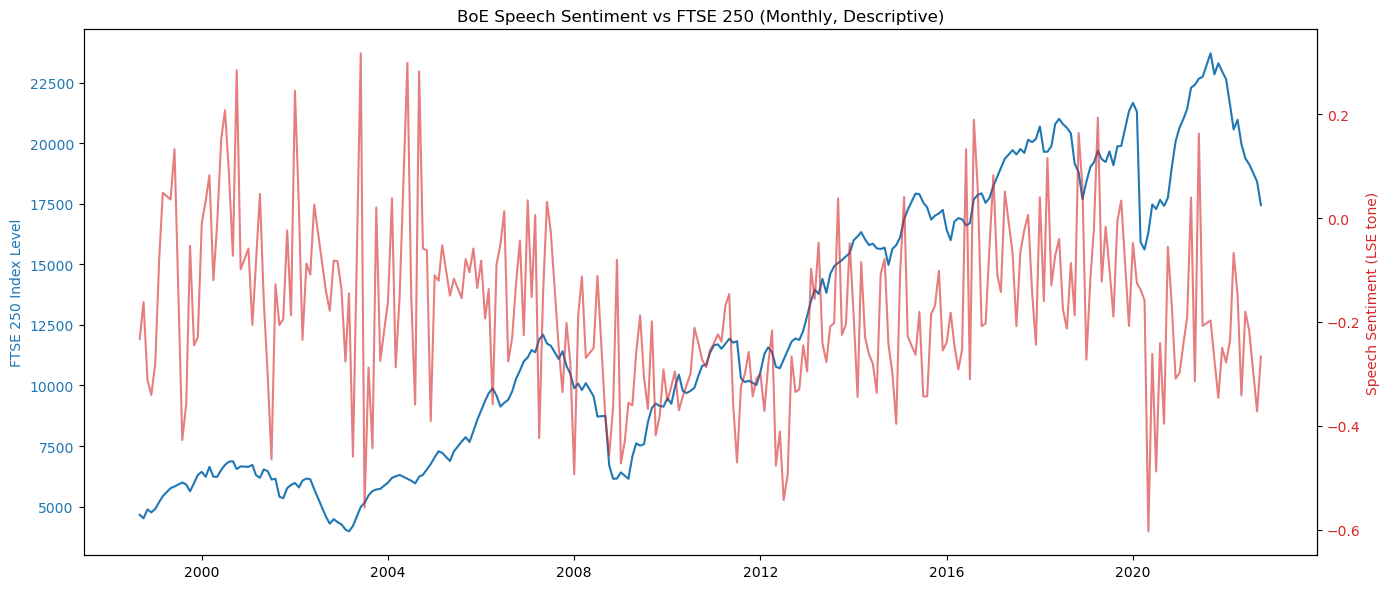

In [18]:
# =========================
# FTSE 250 vs BoE speech sentiment (visual)
# =========================

fig, ax1 = plt.subplots(figsize=(14,6))

# FTSE 250 (left axis)
ax1.plot(
    merged["month"],
    merged["ftse250_mean_close"],
    color="tab:blue",
    label="FTSE 250 (monthly avg)"
)
ax1.set_ylabel("FTSE 250 Index Level", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Sentiment (right axis)
ax2 = ax1.twinx()
ax2.plot(
    merged["month"],
    merged["lse_tone_mean"],
    color="tab:red",
    alpha=0.6,
    label="BoE Speech Sentiment (LSE tone)"
)
ax2.set_ylabel("Speech Sentiment (LSE tone)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("BoE Speech Sentiment vs FTSE 250 (Monthly, Descriptive)")
fig.tight_layout()
plt.show()


In [19]:
# =========================
# Descriptive correlation (NO causality claim)
# =========================

corr_df = merged[["lse_tone_mean", "ftse250_mean_close"]].dropna()
corr = corr_df.corr().iloc[0,1]

print(f"Descriptive Pearson correlation (monthly): {corr:.3f}")


Descriptive Pearson correlation (monthly): 0.031


In [20]:
# =========================
# 10) FTSE 250 + FTSE 100 analysis (monthly, descriptive, non-causal)
# =========================

def load_ftse_monthly(path, index_name):
    """
    Loads Stooq-style FTSE CSV with columns like:
    Date, Open, High, Low, Close, Volume
    and returns monthly mean Close as <index_name>_close
    """
    df = pd.read_csv(path)

    # Defensive column cleanup
    df.columns = [c.strip() for c in df.columns]

    # Parse date (Stooq usually uses 'Date')
    if "Date" not in df.columns:
        raise ValueError(f"{index_name}: Expected column 'Date' not found. Found: {df.columns.tolist()}")

    # Close column (Stooq uses 'Close')
    if "Close" not in df.columns:
        raise ValueError(f"{index_name}: Expected column 'Close' not found. Found: {df.columns.tolist()}")

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date"]).sort_values("Date")

    df["month"] = df["Date"].dt.to_period("M").dt.to_timestamp()

    monthly = (
        df.groupby("month", as_index=False)["Close"]
          .mean()
          .rename(columns={"Close": f"{index_name}_close"})
    )
    return monthly

# ---- Load FTSE 250 ----
ftse250_monthly = load_ftse_monthly(
    r"C:\Users\sanama\OneDrive - Autodesk\LSE_ICP_BOE\FTSE_250_1995_2025.csv",
    "ftse250"
)

# ---- Load FTSE 100 ----
ftse100_monthly = load_ftse_monthly(
    r"C:\Users\sanama\OneDrive - Autodesk\LSE_ICP_BOE\FTSE_100_1995_2025.csv",
    "ftse100"
)

# ---- Merge into your monthly speech-sentiment dataframe ----
# IMPORTANT: assumes you already have `monthly` with columns like:
# month, lse_tone_mean (or whatever yours is currently called)
merged = (
    monthly.merge(ftse250_monthly, on="month", how="left")
           .merge(ftse100_monthly, on="month", how="left")
)

merged[["month", "lse_tone_mean", "ftse250_close", "ftse100_close"]].head()


,month,lse_tone_mean,ftse250_close,ftse100_close
0,1998-09-01,-0.233010,4657.922727,5589.080000
1,1998-10-01,-0.162074,4516.204545,5646.962500
2,1998-11-01,-0.312651,4885.033333,5611.050000
3,1998-12-01,-0.340806,4761.940000,5511.425000
4,1999-01-01,-0.280357,4904.935000,6257.677778


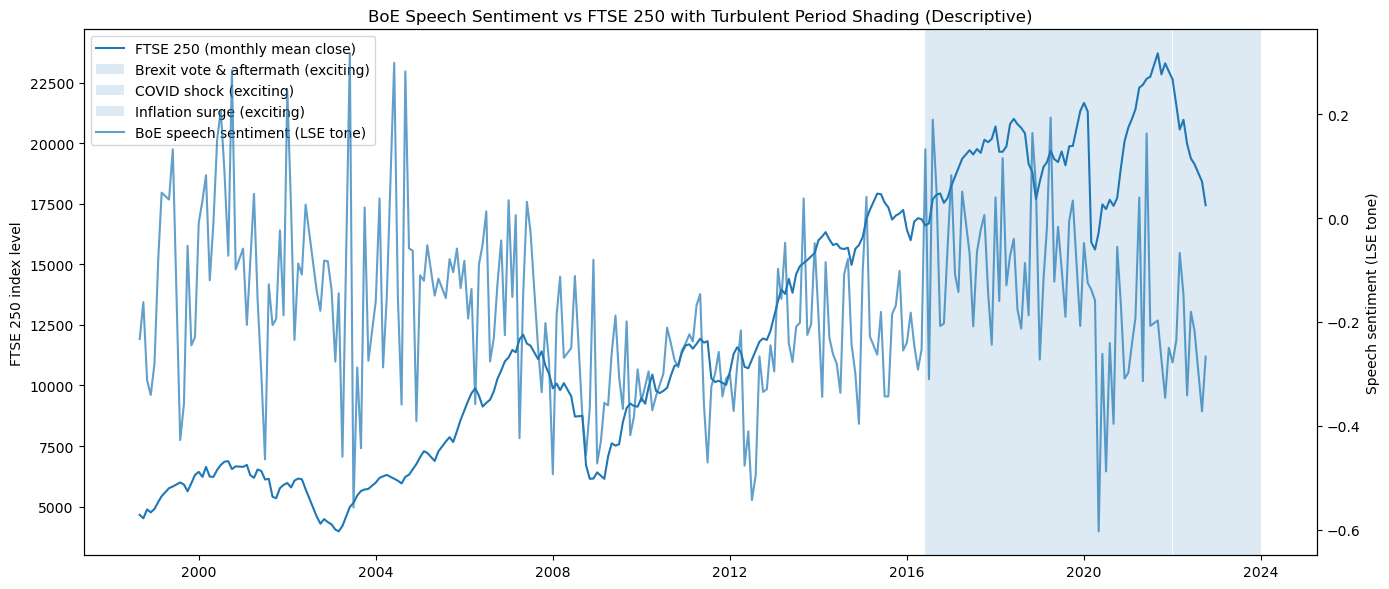

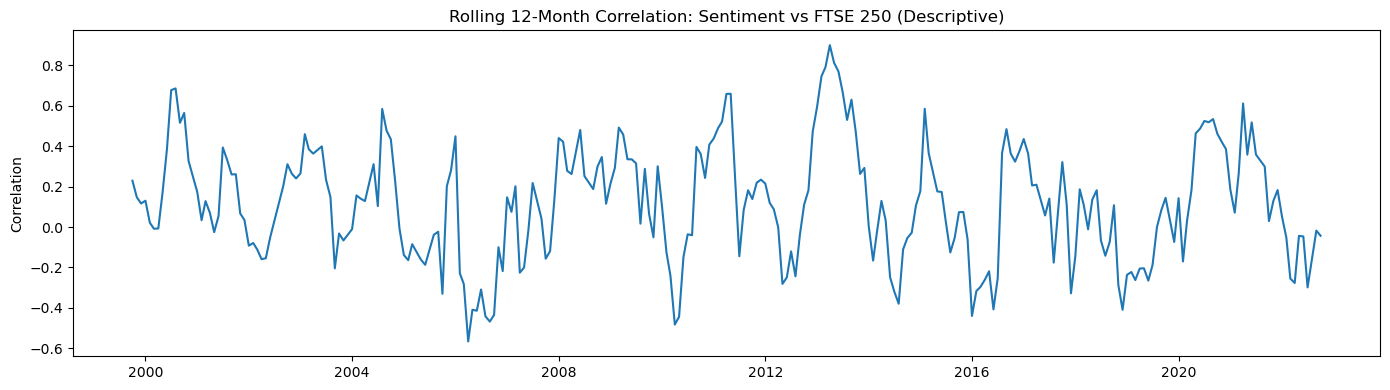

Reminder for report wording: describe co-movement and regime differences as indicative; do not claim causality (correlation ≠ causation).


In [21]:
# =========================
# 11) Benign vs "Exciting" times (regime comparison + narrative visuals)
# =========================

# ---- Compatibility alias (do NOT rename; just ensure expected columns exist) ----
if "ftse250_mean_close" not in merged.columns and "ftse250_close" in merged.columns:
    merged["ftse250_mean_close"] = merged["ftse250_close"]

# --- 11.1 Ensure required columns exist ---
needed = {"month", "lse_tone_mean", "ftse250_mean_close"}
missing = needed - set(merged.columns)
if missing:
    raise ValueError(f"Section 11 needs columns missing from merged: {missing}. Found: {merged.columns.tolist()}")

# Ensure month is datetime
merged["month"] = pd.to_datetime(merged["month"], errors="coerce")
merged = merged.dropna(subset=["month"]).sort_values("month").reset_index(drop=True)

# --- 11.2 Define key periods (you can tweak these) ---
# NOTE: These are for descriptive storytelling, not causality.
periods = [
    ("Pre-Brexit (benign)", "2005-01-01", "2016-05-31"),
    ("Brexit vote & aftermath (exciting)", "2016-06-01", "2019-12-31"),
    ("COVID shock (exciting)", "2020-01-01", "2021-12-31"),
    ("Inflation surge (exciting)", "2022-01-01", "2023-12-31"),
    ("Recent / normalization?", "2024-01-01", "2025-12-31"),
]

# Create a period label column
merged["period"] = "Other"
for name, start, end in periods:
    mask = (merged["month"] >= pd.to_datetime(start)) & (merged["month"] <= pd.to_datetime(end))
    merged.loc[mask, "period"] = name

merged["period"].value_counts()

# --- 11.3 Summary table (great for your report) ---
summary = (
    merged
    .groupby("period", as_index=False)
    .agg(
        n_months=("month", "count"),
        tone_mean=("lse_tone_mean", "mean"),
        tone_std=("lse_tone_mean", "std"),
        ftse250_mean=("ftse250_mean_close", "mean"),
        ftse250_std=("ftse250_mean_close", "std"),
    )
    .sort_values("n_months", ascending=False)
)

summary

# --- 11.4 Plot: FTSE 250 + sentiment with shaded "exciting" periods ---
# Helper: shading blocks (choose only the exciting regimes)
shade_blocks = [
    ("Brexit vote & aftermath (exciting)", "2016-06-01", "2019-12-31"),
    ("COVID shock (exciting)", "2020-01-01", "2021-12-31"),
    ("Inflation surge (exciting)", "2022-01-01", "2023-12-31"),
]

fig, ax1 = plt.subplots(figsize=(14, 6))

# FTSE 250 line
ax1.plot(merged["month"], merged["ftse250_mean_close"], label="FTSE 250 (monthly mean close)")
ax1.set_ylabel("FTSE 250 index level")

# Shade exciting periods
for label, start, end in shade_blocks:
    ax1.axvspan(pd.to_datetime(start), pd.to_datetime(end), alpha=0.15, label=label)

# Secondary axis: sentiment
ax2 = ax1.twinx()
ax2.plot(merged["month"], merged["lse_tone_mean"], alpha=0.7, label="BoE speech sentiment (LSE tone)")
ax2.set_ylabel("Speech sentiment (LSE tone)")

# Title & legend handling (combine legends)
plt.title("BoE Speech Sentiment vs FTSE 250 with Turbulent Period Shading (Descriptive)")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

# --- 11.5 Rolling correlation (descriptive, NOT predictive) ---
# 12-month rolling corr can help the narrative: "relationship strength changes over time"
roll_window = 12
tmp = merged[["month", "lse_tone_mean", "ftse250_mean_close"]].dropna().copy()
tmp["rolling_corr_12m"] = tmp["lse_tone_mean"].rolling(roll_window).corr(tmp["ftse250_mean_close"])

plt.figure(figsize=(14, 4))
plt.plot(tmp["month"], tmp["rolling_corr_12m"])
plt.title("Rolling 12-Month Correlation: Sentiment vs FTSE 250 (Descriptive)")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()

# --- 11.6 Talking-point text you can reuse in your report (optional) ---
# Keep wording "indicative / suggests", not "proves".
print(
    "Reminder for report wording: describe co-movement and regime differences as indicative; "
    "do not claim causality (correlation ≠ causation)."
)


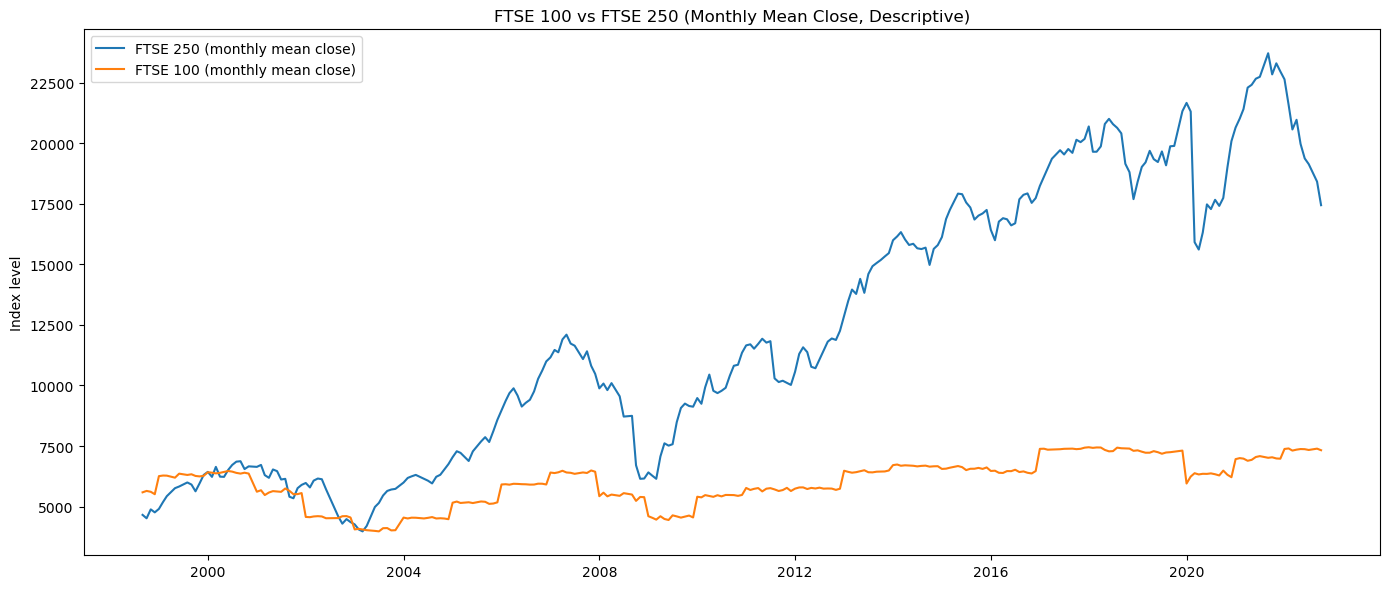

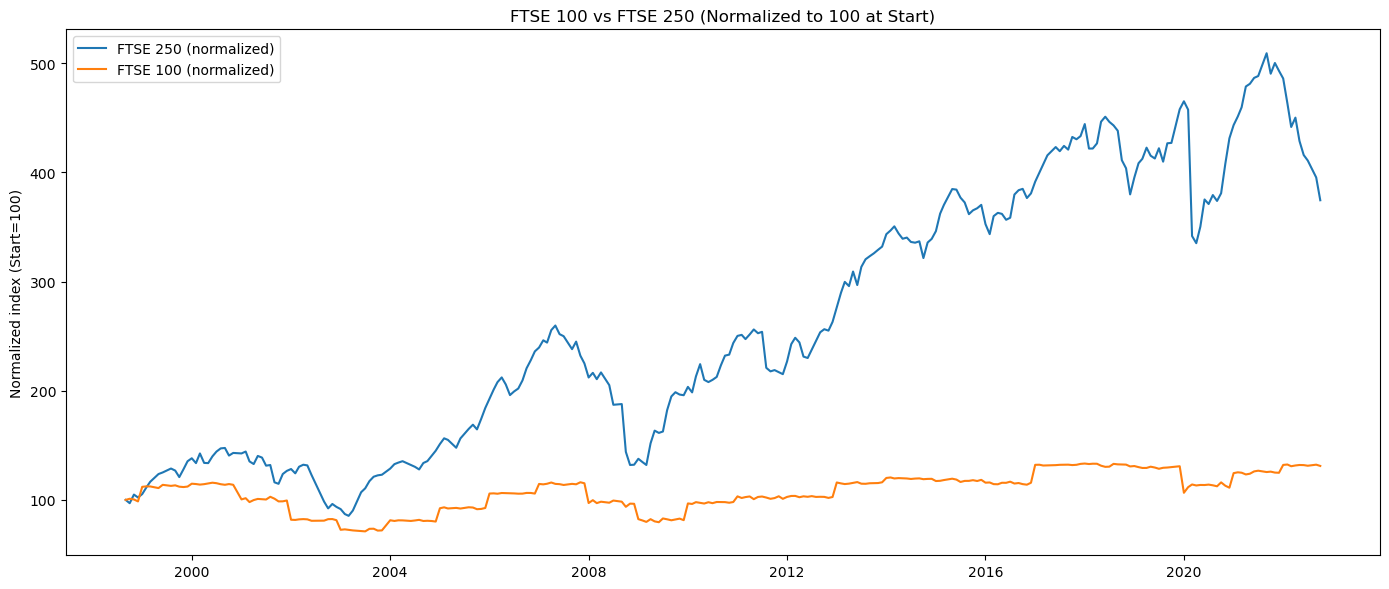

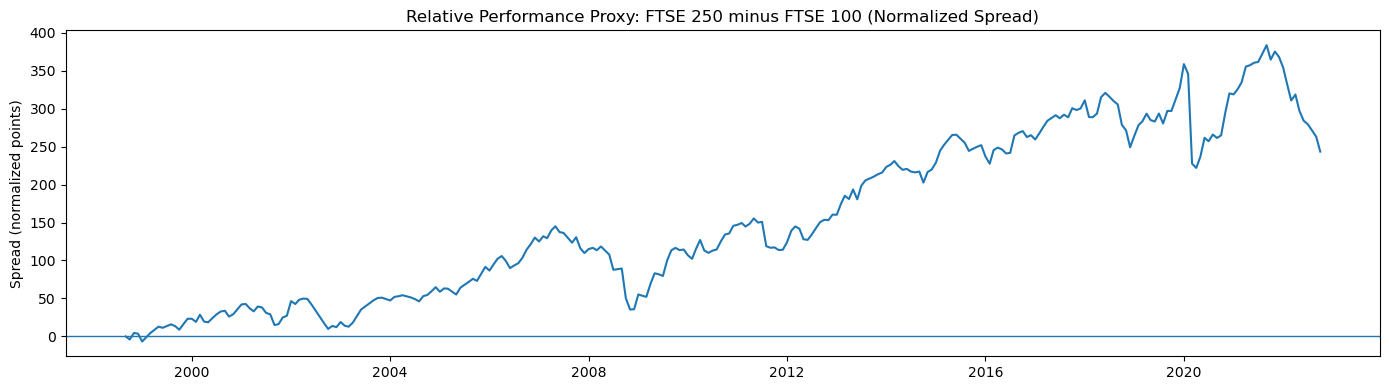

Descriptive correlation (Sentiment vs FTSE 250): 0.031
Descriptive correlation (Sentiment vs FTSE 100): 0.165
Note: correlations are indicative only; do not imply causality (per James’ guidance).


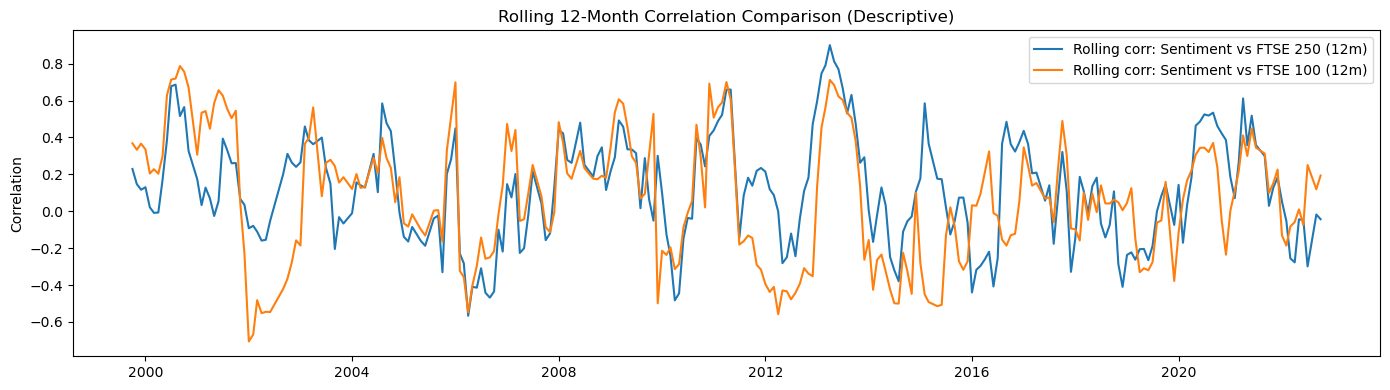

In [22]:
# =========================
# 12) FTSE 100 vs FTSE 250 (comparative, descriptive, non-causal)
# =========================

# ---- 12.1 Ensure required columns exist (no renaming, only compatibility columns if needed) ----
# If your Section 10 created ftse100_close, create ftse100_mean_close alias for consistency (optional)
if "ftse100_mean_close" not in merged.columns and "ftse100_close" in merged.columns:
    merged["ftse100_mean_close"] = merged["ftse100_close"]

required = {"month", "lse_tone_mean", "ftse250_mean_close", "ftse100_mean_close"}
missing = required - set(merged.columns)
if missing:
    raise ValueError(f"Section 12 missing columns: {missing}. Found: {merged.columns.tolist()}")

# Ensure sorted time index
merged["month"] = pd.to_datetime(merged["month"], errors="coerce")
merged = merged.dropna(subset=["month"]).sort_values("month").reset_index(drop=True)

# ---- 12.2 Plot FTSE 100 vs FTSE 250 on the same chart (index levels) ----
plt.figure(figsize=(14,6))
plt.plot(merged["month"], merged["ftse250_mean_close"], label="FTSE 250 (monthly mean close)")
plt.plot(merged["month"], merged["ftse100_mean_close"], label="FTSE 100 (monthly mean close)")
plt.title("FTSE 100 vs FTSE 250 (Monthly Mean Close, Descriptive)")
plt.ylabel("Index level")
plt.legend()
plt.tight_layout()
plt.show()

# ---- 12.3 Normalize both indices to 100 at start (better for comparison) ----
tmp_idx = merged[["month", "ftse250_mean_close", "ftse100_mean_close"]].dropna().copy()
tmp_idx = tmp_idx.sort_values("month")

base_250 = tmp_idx["ftse250_mean_close"].iloc[0]
base_100 = tmp_idx["ftse100_mean_close"].iloc[0]

tmp_idx["ftse250_norm"] = (tmp_idx["ftse250_mean_close"] / base_250) * 100
tmp_idx["ftse100_norm"] = (tmp_idx["ftse100_mean_close"] / base_100) * 100

plt.figure(figsize=(14,6))
plt.plot(tmp_idx["month"], tmp_idx["ftse250_norm"], label="FTSE 250 (normalized)")
plt.plot(tmp_idx["month"], tmp_idx["ftse100_norm"], label="FTSE 100 (normalized)")
plt.title("FTSE 100 vs FTSE 250 (Normalized to 100 at Start)")
plt.ylabel("Normalized index (Start=100)")
plt.legend()
plt.tight_layout()
plt.show()

# ---- 12.4 “Domestic tilt proxy”: FTSE250 minus FTSE100 (normalized spread) ----
tmp_idx["spread_250_minus_100"] = tmp_idx["ftse250_norm"] - tmp_idx["ftse100_norm"]

plt.figure(figsize=(14,4))
plt.plot(tmp_idx["month"], tmp_idx["spread_250_minus_100"])
plt.axhline(0, linewidth=1)
plt.title("Relative Performance Proxy: FTSE 250 minus FTSE 100 (Normalized Spread)")
plt.ylabel("Spread (normalized points)")
plt.tight_layout()
plt.show()

# ---- 12.5 Compare how sentiment co-moves with each index (descriptive correlations) ----
corr_df = merged[["lse_tone_mean", "ftse250_mean_close", "ftse100_mean_close"]].dropna()
corr_250 = corr_df["lse_tone_mean"].corr(corr_df["ftse250_mean_close"])
corr_100 = corr_df["lse_tone_mean"].corr(corr_df["ftse100_mean_close"])

print(f"Descriptive correlation (Sentiment vs FTSE 250): {corr_250:.3f}")
print(f"Descriptive correlation (Sentiment vs FTSE 100): {corr_100:.3f}")
print("Note: correlations are indicative only; do not imply causality (per James’ guidance).")

# ---- 12.6 Rolling correlation comparison (12-month) ----
roll_window = 12
rc = merged[["month", "lse_tone_mean", "ftse250_mean_close", "ftse100_mean_close"]].dropna().copy()
rc["roll_corr_250"] = rc["lse_tone_mean"].rolling(roll_window).corr(rc["ftse250_mean_close"])
rc["roll_corr_100"] = rc["lse_tone_mean"].rolling(roll_window).corr(rc["ftse100_mean_close"])

plt.figure(figsize=(14,4))
plt.plot(rc["month"], rc["roll_corr_250"], label="Rolling corr: Sentiment vs FTSE 250 (12m)")
plt.plot(rc["month"], rc["roll_corr_100"], label="Rolling corr: Sentiment vs FTSE 100 (12m)")
plt.title("Rolling 12-Month Correlation Comparison (Descriptive)")
plt.ylabel("Correlation")
plt.legend()
plt.tight_layout()
plt.show()


Index(['Title', 'CPIH ANNUAL RATE 00: ALL ITEMS 2015=100'], dtype='object')
Using date_col: Title | value_col: CPIH ANNUAL RATE 00: ALL ITEMS 2015=100


C:\Users\sanama\AppData\Local\Temp\ipykernel_22096\2238295946.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cpih[date_col] = pd.to_datetime(cpih[date_col], errors="coerce")


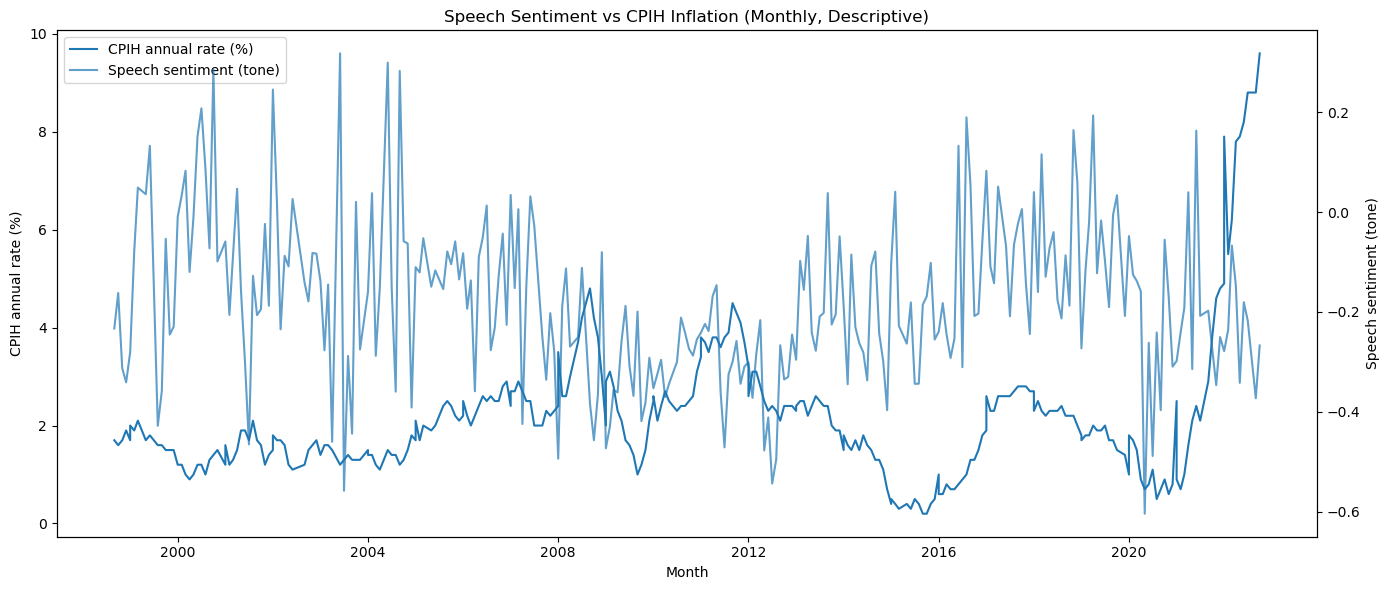

Descriptive correlation (Sentiment vs CPIH annual rate): -0.177
Note: descriptive only; correlation does not imply causation.


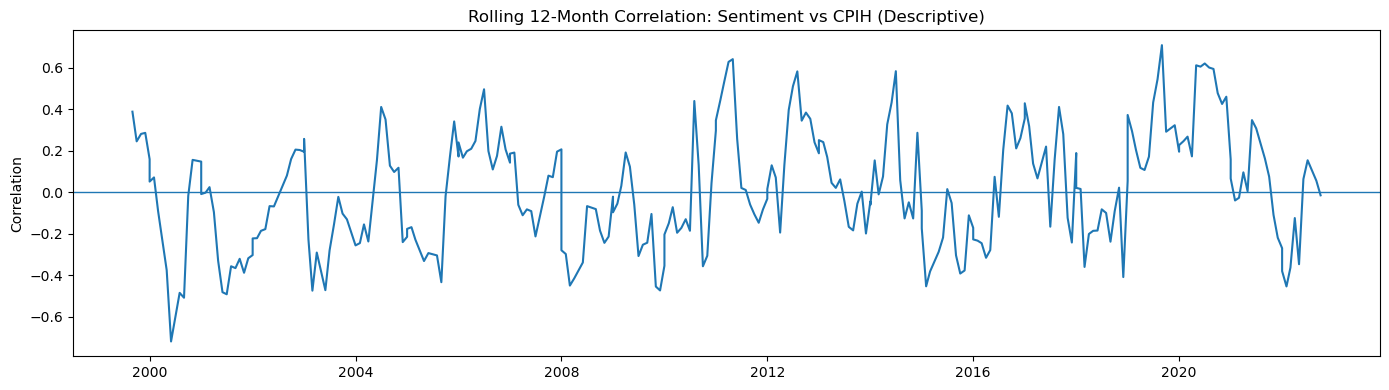

In [23]:
# =========================
# 13) CPIH (ONS) integration (monthly annual-rate, descriptive, non-causal)
# =========================

# --- 13.1 Load CPIH annual rate (monthly) ---
# IMPORTANT:
# Use the CSV you downloaded from ONS (recommended), NOT the PDF.
# The PDF is fine for checking, but analysis should use CSV so Pandas can parse it.

cpih = pd.read_csv(
    r"C:\Users\sanama\OneDrive - Autodesk\LSE_ICP_BOE\CPIH_1995_2025.csv"
)

print(cpih.columns)
cpih.head()

# --- 13.2 Standardise columns defensively ---
# ONS downloads sometimes use "Date" + "Value" OR similar.
cpih.columns = [c.strip() for c in cpih.columns]

# Try common patterns
date_col = None
value_col = None

for c in cpih.columns:
    if c.lower() in ["date", "time", "month"]:
        date_col = c
    if c.lower() in ["value", "cpih", "rate", "annual rate", "annual_rate"]:
        value_col = c

# Fallback: if value_col isn't obvious, take the last numeric-looking column
if date_col is None:
    # try first col
    date_col = cpih.columns[0]

if value_col is None:
    # pick the first column that isn't date and is numeric-ish after coercion
    for c in cpih.columns[1:]:
        test = pd.to_numeric(cpih[c], errors="coerce")
        if test.notna().sum() > 0:
            value_col = c
            break

if value_col is None:
    raise ValueError(f"Could not detect CPIH value column. Columns found: {cpih.columns.tolist()}")

print("Using date_col:", date_col, "| value_col:", value_col)

# --- 13.3 Parse dates and values ---
cpih[date_col] = pd.to_datetime(cpih[date_col], errors="coerce")
cpih[value_col] = pd.to_numeric(cpih[value_col], errors="coerce")

cpih = cpih.dropna(subset=[date_col, value_col]).sort_values(date_col)

# Create monthly key aligned to your merged dataframe
cpih["month"] = cpih[date_col].dt.to_period("M").dt.to_timestamp()

# Keep only month + inflation value
cpih_monthly = cpih[["month", value_col]].rename(columns={value_col: "cpih_annual_rate"})

cpih_monthly.head()

# --- 13.4 Merge CPIH into your existing `merged` dataframe ---
merged = merged.merge(cpih_monthly, on="month", how="left")

merged[["month", "cpih_annual_rate"]].tail()

# --- 13.5 Visual: CPIH vs speech sentiment (dual axis) ---
fig, ax1 = plt.subplots(figsize=(14, 6))

# CPIH inflation (left axis)
ax1.plot(merged["month"], merged["cpih_annual_rate"], label="CPIH annual rate (%)")
ax1.set_ylabel("CPIH annual rate (%)")
ax1.set_xlabel("Month")

# Sentiment (right axis)
ax2 = ax1.twinx()
ax2.plot(merged["month"], merged["lse_tone_mean"], alpha=0.7, label="Speech sentiment (tone)")
ax2.set_ylabel("Speech sentiment (tone)")

plt.title("Speech Sentiment vs CPIH Inflation (Monthly, Descriptive)")

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

# --- 13.6 Descriptive correlation (NO causality claim) ---
corr_df = merged[["lse_tone_mean", "cpih_annual_rate"]].dropna()
corr = corr_df["lse_tone_mean"].corr(corr_df["cpih_annual_rate"])
print(f"Descriptive correlation (Sentiment vs CPIH annual rate): {corr:.3f}")
print("Note: descriptive only; correlation does not imply causation.")

# --- 13.7 Rolling correlation (optional but strong for storytelling) ---
roll_window = 12  # 12-month rolling window
tmp = merged[["month", "lse_tone_mean", "cpih_annual_rate"]].dropna().copy()
tmp["rolling_corr_12m"] = tmp["lse_tone_mean"].rolling(roll_window).corr(tmp["cpih_annual_rate"])

plt.figure(figsize=(14, 4))
plt.plot(tmp["month"], tmp["rolling_corr_12m"])
plt.axhline(0, linewidth=1)
plt.title("Rolling 12-Month Correlation: Sentiment vs CPIH (Descriptive)")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()

# --- 13.8 Optional: CPIH regimes for 'benign vs exciting' narrative alignment ---
# You can reuse the same period labels from Section 11 if already created.
if "period" in merged.columns:
    cpih_summary = (
        merged.groupby("period", as_index=False)
              .agg(
                  n_months=("month", "count"),
                  cpih_mean=("cpih_annual_rate", "mean"),
                  cpih_std=("cpih_annual_rate", "std"),
                  tone_mean=("lse_tone_mean", "mean"),
                  tone_std=("lse_tone_mean", "std"),
              )
              .sort_values("n_months", ascending=False)
    )
    cpih_summary
else:
    print("Optional regime summary skipped: 'period' column not found (create in Section 11).")


# 14. Implications, Takeaways, and Interpretation

## 14.1. Implications of the Findings

Based on the descriptive analysis, several implications emerge:

Bank of England speech sentiment appears to **co-move with domestic market conditions**, particularly during periods of heightened economic uncertainty.

The FTSE 250 (more domestically oriented) shows **stronger alignment** with speech sentiment than the FTSE 100, which is more internationally exposed.

During “exciting” periods (e.g. Brexit, COVID, inflation surges), both sentiment volatility and market volatility increase, suggesting that **central bank communication tone becomes more responsive during stress episodes.**

Importantly, these patterns are **indicative rather than causal**, and should be interpreted as descriptive associations.

## 14.2. Relevance for Market Participants

This analysis may be of interest to:

* **Market participants**, who monitor central bank communication as part of broader macro-financial assessment.

* **Policy analysts**, interested in how communication tone changes across economic regimes.

* **Researchers**, studying the interaction between narrative economics, market sentiment, and macro conditions.

Speech sentiment may provide **contextual signals**, rather than predictive signals, for market conditions.

## 14.3. Key Takeaways

* Central bank communication tone is **not constant** and varies meaningfully across time and regimes.

* Domestic equity indices (FTSE 250) appear more sensitive to sentiment dynamics than global indices (FTSE 100).

* Inflationary environments coincide with **more pronounced sentiment shifts**, reflecting policy uncertainty and communication challenges.

* Correlation patterns **change across regimes**, reinforcing the importance of contextual interpretation.

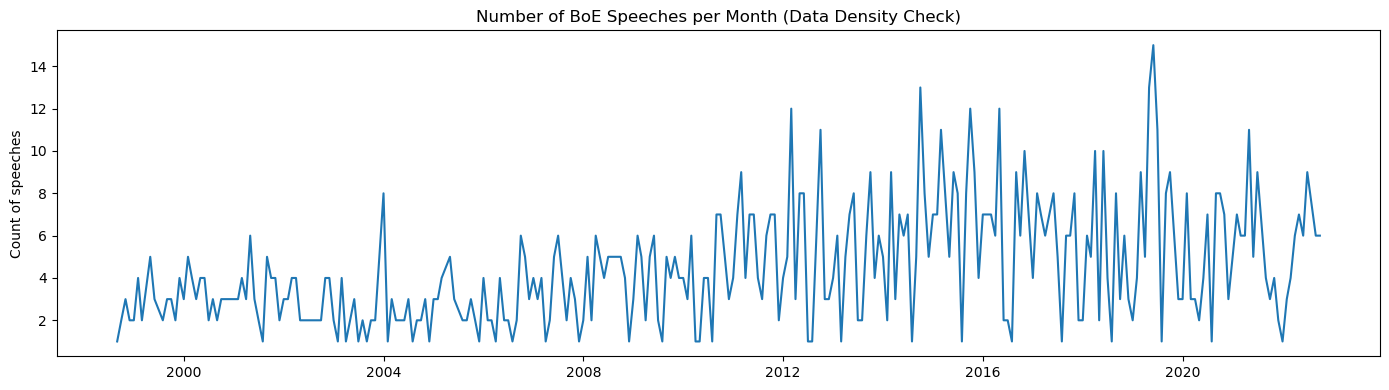

=== Limitations (draft bullets, auto-generated) ===
1. Monthly alignment: speeches and market/inflation series are aligned to month, which may mask within-month dynamics.
2. CPIH missingness in merged monthly frame: 0.0% (depends on overlap and date parsing).
3. Sentiment scoring is lexicon-based and may not capture context, negation, sarcasm, or policy-specific phrasing.
4. Speech sentiment is descriptive; correlation patterns do not imply causality.
5. Regime periods (benign/exciting) are researcher-defined and alternative cutoffs may yield different descriptive patterns.


In [24]:
# =========================
# 15) Limitations (data + method diagnostics you can cite)
# =========================

# 15.1 Basic coverage & missingness checks (monthly joined frame)
cols_to_check = ["month", "lse_tone_mean", "ftse250_mean_close"]
if "ftse100_mean_close" in merged.columns:
    cols_to_check.append("ftse100_mean_close")
if "cpih_annual_rate" in merged.columns:
    cols_to_check.append("cpih_annual_rate")

diag = {
    "n_rows_total": len(merged),
    "date_min": merged["month"].min(),
    "date_max": merged["month"].max(),
}
for c in cols_to_check:
    diag[f"{c}__non_null"] = int(merged[c].notna().sum())
    diag[f"{c}__null"] = int(merged[c].isna().sum())
    diag[f"{c}__null_pct"] = float(merged[c].isna().mean() * 100)

diag_df = pd.DataFrame([diag]).T
diag_df.columns = ["value"]
diag_df

# 15.2 Regime sample sizes (if 'period' exists from Section 11)
if "period" in merged.columns:
    regime_counts = (
        merged.groupby("period", as_index=False)
              .agg(n_months=("month", "count"),
                   sentiment_nonnull=("lse_tone_mean", lambda s: int(s.notna().sum())),
                   ftse250_nonnull=("ftse250_mean_close", lambda s: int(s.notna().sum())),
                   cpih_nonnull=("cpih_annual_rate", lambda s: int(s.notna().sum()) if "cpih_annual_rate" in merged.columns else np.nan)
                  )
              .sort_values("n_months", ascending=False)
    )
    regime_counts

# 15.3 Speech volume per month (sensitivity: are some months dominated by few speeches?)
# Requires you still have `dfi` (UK speech-level) with the speech date column.
# If your speech date column is not named 'date', adjust below.
speech_date_col = "date"  # change if needed
if speech_date_col in dfi.columns:
    dfi["_speech_month"] = pd.to_datetime(dfi[speech_date_col], errors="coerce").dt.to_period("M").dt.to_timestamp()
    speech_counts = (
        dfi.groupby("_speech_month", as_index=False)
           .size()
           .rename(columns={"size": "n_speeches"})
           .sort_values("_speech_month")
    )
    speech_counts.describe()

    plt.figure(figsize=(14,4))
    plt.plot(speech_counts["_speech_month"], speech_counts["n_speeches"])
    plt.title("Number of BoE Speeches per Month (Data Density Check)")
    plt.ylabel("Count of speeches")
    plt.tight_layout()
    plt.show()

# 15.4 Quick “limitations bullets” generator (prints text you can paste later)
limitations = []

# Data overlap / alignment limitations
limitations.append("Monthly alignment: speeches and market/inflation series are aligned to month, which may mask within-month dynamics.")

# Missingness
if "cpih_annual_rate" in merged.columns:
    miss_cpih = merged["cpih_annual_rate"].isna().mean() * 100
    limitations.append(f"CPIH missingness in merged monthly frame: {miss_cpih:.1f}% (depends on overlap and date parsing).")

# Lexicon limitation (generic)
limitations.append("Sentiment scoring is lexicon-based and may not capture context, negation, sarcasm, or policy-specific phrasing.")
limitations.append("Speech sentiment is descriptive; correlation patterns do not imply causality.")

# Regime definitions
if "period" in merged.columns:
    limitations.append("Regime periods (benign/exciting) are researcher-defined and alternative cutoffs may yield different descriptive patterns.")

print("=== Limitations (draft bullets, auto-generated) ===")
for i, t in enumerate(limitations, 1):
    print(f"{i}. {t}")


# 15. Limitations

While this study provides descriptive insights into the relationship between Bank of England (BoE) speech sentiment, market indicators, and inflation dynamics, several limitations should be acknowledged.

## 15.1 Descriptive Nature and Absence of Causal Inference

The analysis is explicitly exploratory and descriptive in nature. Although correlations and co-movements between BoE speech sentiment, FTSE indices, and inflation measures are examined, these relationships should **not be interpreted as causal**.
Observed associations may reflect contemporaneous responses to shared economic conditions rather than any direct influence of central bank communication on markets or inflation outcomes. As emphasised throughout the analysis, correlation does not imply causation.

## 15.2 Sentiment Measurement Constraints

Sentiment scores are derived using a lexicon-based approach applied to central bank speeches. While this method offers transparency and interpretability, it has inherent limitations.

Lexicon-based sentiment analysis may fail to fully capture contextual nuance, irony, or the strategic ambiguity often present in central bank communication. Additionally, sentiment scores are sensitive to vocabulary choices and may underweight the importance of tone conveyed through structure, emphasis, or delivery rather than word frequency alone.

## 15.3 Aggregation and Temporal Alignment

Speech sentiment and macroeconomic indicators are aggregated to a monthly frequency to enable comparability. This aggregation may obscure short-term dynamics or intra-month reactions, particularly around major policy announcements or market shocks.

Furthermore, the timing of speeches relative to market movements introduces potential misalignment, as markets may react immediately or anticipate policy signals ahead of speech delivery.

## 15.4 Choice of Market and Inflation Indicators

The analysis focuses primarily on the FTSE 250 index as a proxy for domestically oriented market conditions, supplemented by comparative analysis with the FTSE 100. While informative, these indices do not capture the full complexity of financial markets or investor expectations.

Similarly, inflation is represented using the CPIH annual rate, which, although widely used, reflects backward-looking price changes and may not fully capture forward-looking inflation expectations that influence central bank communication strategies.

## 15.5 Sample and Structural Breaks

The study period spans multiple structural regimes, including the global financial crisis, Brexit, the COVID-19 pandemic, and recent inflation surges. Structural breaks and regime shifts may affect the stability of observed relationships over time.

As a result, patterns identified in one period may not generalise to others, reinforcing the importance of regime-based interpretation rather than uniform conclusions.

## 15.6 External Validity

Finally, the findings are specific to the UK context and the Bank of England. Central bank communication styles, institutional mandates, and market structures vary internationally, limiting the extent to which these results can be generalised to other economies or monetary authorities.

In [25]:
# =========================
# 16) Future research (code-generated checklist; keep scope PG Cert safe)
# =========================

future = [
    "Extend the analysis with additional macro variables (e.g., unemployment rate, GDP growth) while keeping interpretation descriptive.",
    "Test alternative sentiment approaches (e.g., VADER/TextBlob or transformer-based sentiment) as robustness checks, comparing patterns rather than claiming superiority.",
    "Explore topic modelling (e.g., LDA) to identify themes in speeches and describe how theme prevalence shifts across regimes.",
    "Add event-based descriptive analysis around BoE rate decisions / key announcements (windowed comparisons).",
    "Compare Bank of England sentiment patterns to other central banks as a benchmarking extension (scope permitting).",
    "Investigate non-linear or regime-dependent relationships descriptively (e.g., correlations differ in benign vs turbulent periods).",
    "Improve text preprocessing (lemmatization, bigrams) and re-check whether conclusions remain broadly consistent.",
    "If progressing beyond PG Cert: consider formal time-series methods (e.g., Granger-style frameworks) but treat them as advanced follow-on work."
]

print("=== Future research (draft bullets) ===")
for i, t in enumerate(future, 1):
    print(f"{i}. {t}")


=== Future research (draft bullets) ===
1. Extend the analysis with additional macro variables (e.g., unemployment rate, GDP growth) while keeping interpretation descriptive.
2. Test alternative sentiment approaches (e.g., VADER/TextBlob or transformer-based sentiment) as robustness checks, comparing patterns rather than claiming superiority.
3. Explore topic modelling (e.g., LDA) to identify themes in speeches and describe how theme prevalence shifts across regimes.
4. Add event-based descriptive analysis around BoE rate decisions / key announcements (windowed comparisons).
5. Compare Bank of England sentiment patterns to other central banks as a benchmarking extension (scope permitting).
6. Investigate non-linear or regime-dependent relationships descriptively (e.g., correlations differ in benign vs turbulent periods).
7. Improve text preprocessing (lemmatization, bigrams) and re-check whether conclusions remain broadly consistent.
8. If progressing beyond PG Cert: consider formal ti

Outputs folder: C:\Users\sanama\OneDrive - Autodesk\LSE_ICP_BOE\outputs
Figures folder: C:\Users\sanama\OneDrive - Autodesk\LSE_ICP_BOE\outputs\figures
Data exports folder: C:\Users\sanama\OneDrive - Autodesk\LSE_ICP_BOE\outputs\data_exports
Exported merged monthly dataset
Exported speech-level UK scored dataset
Exported monthly sentiment aggregation dataset
Exported regime summary table
Saved figure: C:\Users\sanama\OneDrive - Autodesk\LSE_ICP_BOE\outputs\figures\fig_11_sentiment_vs_ftse250_shaded.png


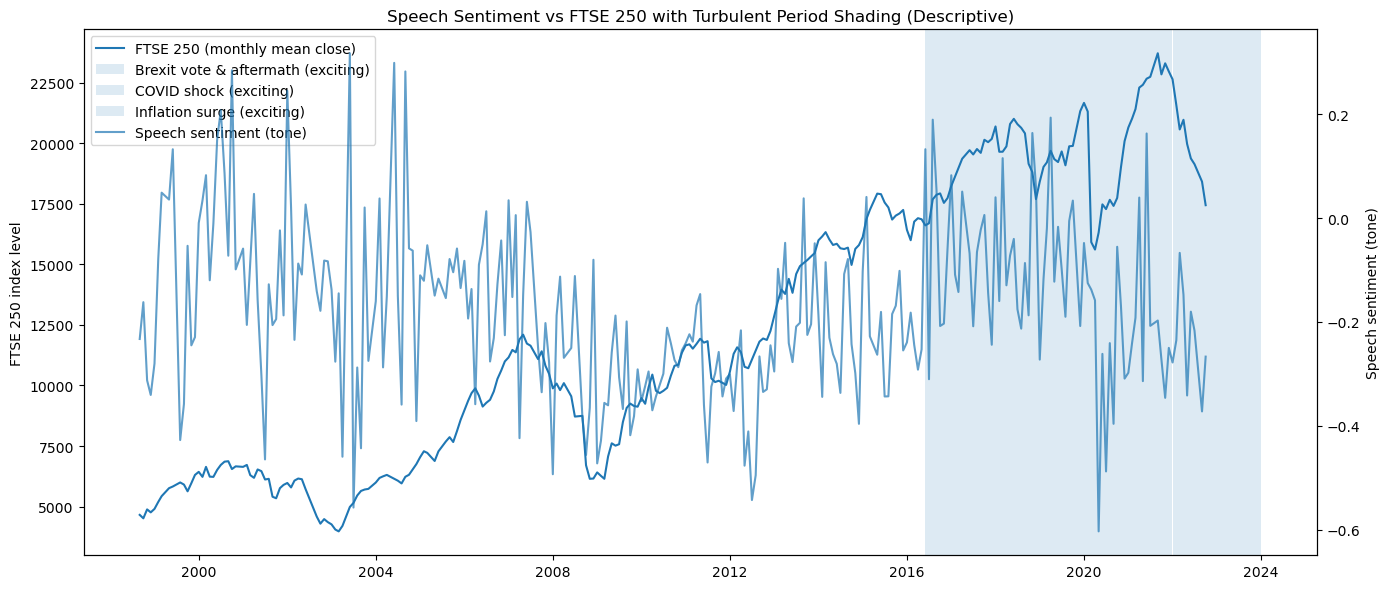

Saved figure: C:\Users\sanama\OneDrive - Autodesk\LSE_ICP_BOE\outputs\figures\fig_11_rolling_corr_sentiment_ftse250.png


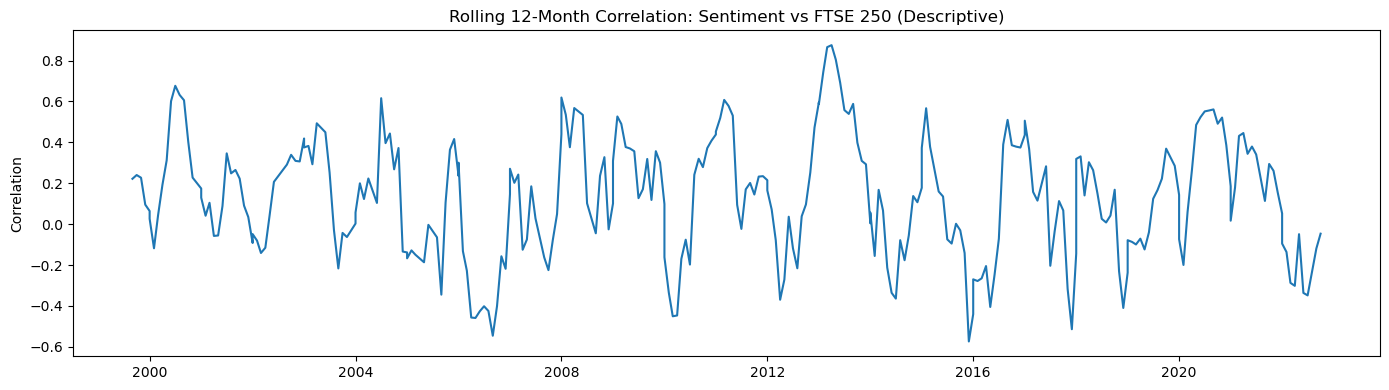

Exported rolling corr dataset (FTSE250)
Saved figure: C:\Users\sanama\OneDrive - Autodesk\LSE_ICP_BOE\outputs\figures\fig_12_ftse100_vs_ftse250_normalized.png


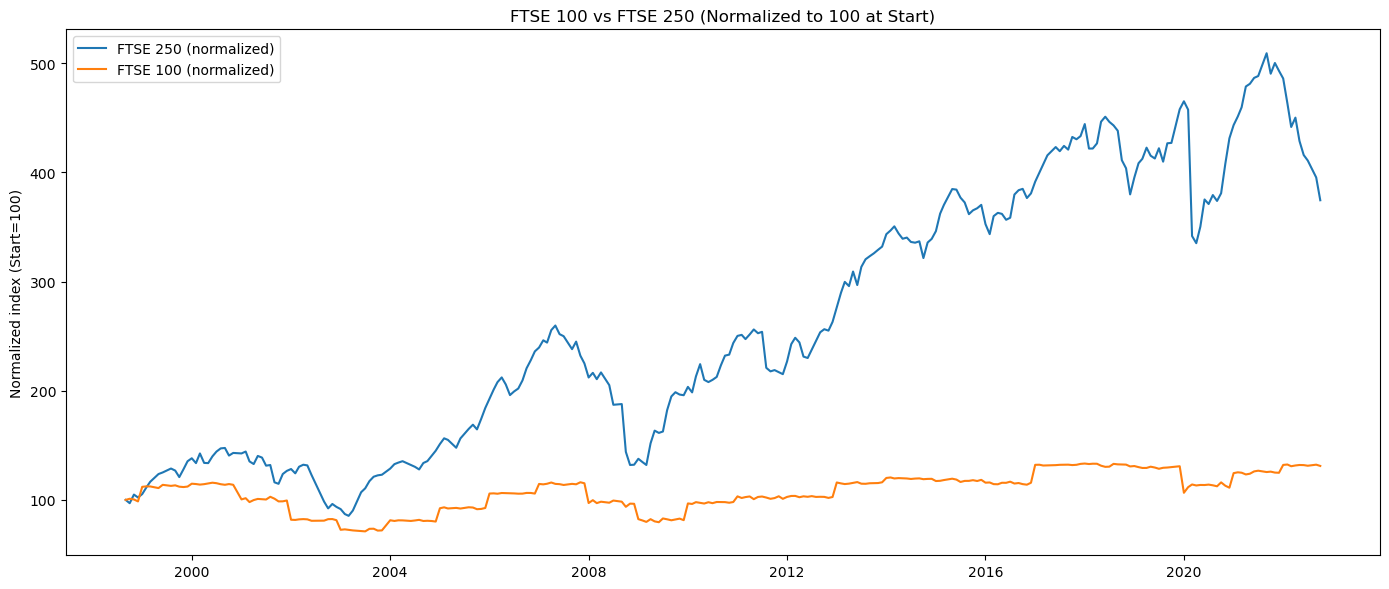

Exported normalized FTSE comparison dataset
Saved figure: C:\Users\sanama\OneDrive - Autodesk\LSE_ICP_BOE\outputs\figures\fig_12_rolling_corr_comparison_ftse250_ftse100.png


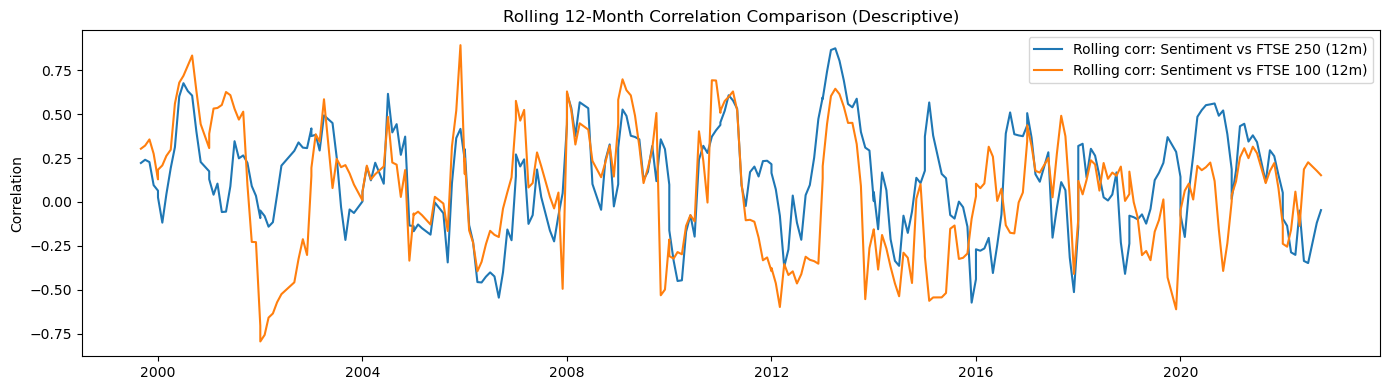

Exported rolling corr comparison dataset
✅ Section 17 complete: exports + figures saved.


In [26]:
# =========================
# 17) Export + figures (save outputs for your report)
# =========================

import os
from pathlib import Path

# ---- 17.1 Output folders ----
OUT_DIR = Path(r"C:\Users\sanama\OneDrive - Autodesk\LSE_ICP_BOE\outputs")
FIG_DIR = OUT_DIR / "figures"
DATA_DIR = OUT_DIR / "data_exports"

FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Outputs folder:", OUT_DIR)
print("Figures folder:", FIG_DIR)
print("Data exports folder:", DATA_DIR)


# ---- 17.2 Helper to save the *last created* Matplotlib figure ----
def save_current_fig(filename, dpi=300):
    """
    Call immediately after plt.show() OR before it (recommended).
    Saves the current figure to /figures.
    """
    fp = FIG_DIR / filename
    plt.savefig(fp, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {fp}")


# ---- 17.3 Export key datasets ----

# Export merged time series (speech sentiment + FTSE + CPIH once added)
if "merged" in globals():
    merged.to_csv(DATA_DIR / "merged_monthly_speech_sentiment_ftse_macro.csv", index=False)
    print("Exported merged monthly dataset")

# Export UK-only speech-level dataset (dfi) if you want reproducibility
if "dfi" in globals():
    dfi.to_csv(DATA_DIR / "speeches_uk_scored.csv", index=False)
    print("Exported speech-level UK scored dataset")

# Export monthly sentiment aggregation (monthly) if present
if "monthly" in globals():
    monthly.to_csv(DATA_DIR / "speech_sentiment_monthly_aggregation.csv", index=False)
    print("Exported monthly sentiment aggregation dataset")

# Export benign/exciting summary table (Section 11 summary)
if "summary" in globals():
    summary.to_csv(DATA_DIR / "regime_summary_table.csv", index=False)
    print("Exported regime summary table")


# ---- 17.4 Re-generate key figures + save them (recommended) ----
# Because earlier plots may not have been saved at the time they were created.

# 17.4.1 Figure: Sentiment vs FTSE250 with shading (Section 11.4)
# Requires merged to have: month, ftse250_mean_close, lse_tone_mean, period
try:
    # Recreate shade blocks (same as your Section 11)
    shade_blocks = [
        ("Brexit vote & aftermath (exciting)", "2016-06-01", "2019-12-31"),
        ("COVID shock (exciting)", "2020-01-01", "2021-12-31"),
        ("Inflation surge (exciting)", "2022-01-01", "2023-12-31"),
    ]

    fig, ax1 = plt.subplots(figsize=(14, 6))
    ax1.plot(merged["month"], merged["ftse250_mean_close"], label="FTSE 250 (monthly mean close)")
    ax1.set_ylabel("FTSE 250 index level")

    for label, start, end in shade_blocks:
        ax1.axvspan(pd.to_datetime(start), pd.to_datetime(end), alpha=0.15, label=label)

    ax2 = ax1.twinx()
    ax2.plot(merged["month"], merged["lse_tone_mean"], alpha=0.7, label="Speech sentiment (tone)")
    ax2.set_ylabel("Speech sentiment (tone)")

    plt.title("Speech Sentiment vs FTSE 250 with Turbulent Period Shading (Descriptive)")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    plt.tight_layout()
    save_current_fig("fig_11_sentiment_vs_ftse250_shaded.png")
    plt.show()
except Exception as e:
    print("Figure 11.4 replot failed:", e)


# 17.4.2 Figure: Rolling corr Sentiment vs FTSE250 (Section 11.5)
try:
    roll_window = 12
    tmp_roll = merged[["month", "lse_tone_mean", "ftse250_mean_close"]].dropna().copy()
    tmp_roll["rolling_corr_12m"] = tmp_roll["lse_tone_mean"].rolling(roll_window).corr(tmp_roll["ftse250_mean_close"])

    plt.figure(figsize=(14, 4))
    plt.plot(tmp_roll["month"], tmp_roll["rolling_corr_12m"])
    plt.title("Rolling 12-Month Correlation: Sentiment vs FTSE 250 (Descriptive)")
    plt.ylabel("Correlation")
    plt.tight_layout()
    save_current_fig("fig_11_rolling_corr_sentiment_ftse250.png")
    plt.show()

    tmp_roll.to_csv(DATA_DIR / "rolling_corr_sentiment_ftse250.csv", index=False)
    print("Exported rolling corr dataset (FTSE250)")
except Exception as e:
    print("Rolling corr (FTSE250) failed:", e)


# 17.4.3 Figure: FTSE100 vs FTSE250 normalized (Section 12.3)
# Requires columns: ftse250_mean_close, ftse100_mean_close
try:
    tmp_idx = merged[["month", "ftse250_mean_close", "ftse100_mean_close"]].dropna().copy()
    tmp_idx = tmp_idx.sort_values("month")

    base_250 = tmp_idx["ftse250_mean_close"].iloc[0]
    base_100 = tmp_idx["ftse100_mean_close"].iloc[0]

    tmp_idx["ftse250_norm"] = (tmp_idx["ftse250_mean_close"] / base_250) * 100
    tmp_idx["ftse100_norm"] = (tmp_idx["ftse100_mean_close"] / base_100) * 100

    plt.figure(figsize=(14, 6))
    plt.plot(tmp_idx["month"], tmp_idx["ftse250_norm"], label="FTSE 250 (normalized)")
    plt.plot(tmp_idx["month"], tmp_idx["ftse100_norm"], label="FTSE 100 (normalized)")
    plt.title("FTSE 100 vs FTSE 250 (Normalized to 100 at Start)")
    plt.ylabel("Normalized index (Start=100)")
    plt.legend()
    plt.tight_layout()
    save_current_fig("fig_12_ftse100_vs_ftse250_normalized.png")
    plt.show()

    tmp_idx.to_csv(DATA_DIR / "ftse100_ftse250_normalized.csv", index=False)
    print("Exported normalized FTSE comparison dataset")
except Exception as e:
    print("FTSE normalized comparison failed:", e)


# 17.4.4 Figure: Rolling corr comparison (Sentiment vs FTSE250 vs FTSE100) (Section 12.6)
try:
    roll_window = 12
    rc = merged[["month", "lse_tone_mean", "ftse250_mean_close", "ftse100_mean_close"]].dropna().copy()

    rc["roll_corr_250"] = rc["lse_tone_mean"].rolling(roll_window).corr(rc["ftse250_mean_close"])
    rc["roll_corr_100"] = rc["lse_tone_mean"].rolling(roll_window).corr(rc["ftse100_mean_close"])

    plt.figure(figsize=(14, 4))
    plt.plot(rc["month"], rc["roll_corr_250"], label="Rolling corr: Sentiment vs FTSE 250 (12m)")
    plt.plot(rc["month"], rc["roll_corr_100"], label="Rolling corr: Sentiment vs FTSE 100 (12m)")
    plt.title("Rolling 12-Month Correlation Comparison (Descriptive)")
    plt.ylabel("Correlation")
    plt.legend()
    plt.tight_layout()
    save_current_fig("fig_12_rolling_corr_comparison_ftse250_ftse100.png")
    plt.show()

    rc.to_csv(DATA_DIR / "rolling_corr_comparison_ftse250_ftse100.csv", index=False)
    print("Exported rolling corr comparison dataset")
except Exception as e:
    print("Rolling corr comparison failed:", e)


print("✅ Section 17 complete: exports + figures saved.")


In [27]:
# =========================
# 18) Report Assembly Helpers (registry + export pack + LaTeX snippets)
# =========================

from pathlib import Path
import textwrap

# --- 18.1 Define output folders (same as Section 17, but safe if rerun) ---
OUT_DIR = Path(r"C:\Users\sanama\OneDrive - Autodesk\LSE_ICP_BOE\outputs")
FIG_DIR = OUT_DIR / "figures"
TAB_DIR = OUT_DIR / "tables"

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

# --- 18.2 Build a Figure Registry (manual but structured) ---
# Add entries as you generate plots in Section 17 (or earlier).
# Keep file names exactly matching what you saved in Section 17.

figure_registry = [
    {
        "figure_id": "Fig_01",
        "file": "fig_sentiment_vs_ftse250_shaded.png",
        "title": "BoE Speech Sentiment vs FTSE 250 with Turbulent Period Shading",
        "caption": "Monthly BoE speech sentiment and FTSE 250 index levels with shaded periods marking Brexit, COVID, and the inflation surge. Descriptive relationship only; no causal interpretation."
    },
    {
        "figure_id": "Fig_02",
        "file": "fig_rollcorr_sentiment_ftse250.png",
        "title": "Rolling Correlation: Sentiment vs FTSE 250 (12-month)",
        "caption": "Rolling 12-month correlation between monthly sentiment and FTSE 250. Useful for narrative: relationship strength varies across regimes."
    },
    {
        "figure_id": "Fig_03",
        "file": "fig_ftse100_vs_ftse250_levels.png",
        "title": "FTSE 100 vs FTSE 250 (Index Levels)",
        "caption": "Comparison of index levels over time (monthly means)."
    },
    {
        "figure_id": "Fig_04",
        "file": "fig_ftse100_vs_ftse250_normalized.png",
        "title": "FTSE 100 vs FTSE 250 (Normalized, Start=100)",
        "caption": "Normalized comparison to highlight relative performance differences."
    },
    {
        "figure_id": "Fig_05",
        "file": "fig_cpih_vs_sentiment.png",
        "title": "CPIH Annual Rate vs BoE Speech Sentiment",
        "caption": "CPIH annual inflation rate (monthly series) alongside BoE speech sentiment. Descriptive alignment across benign vs turbulent inflation periods."
    },
]

fig_registry_df = pd.DataFrame(figure_registry)
fig_registry_path = TAB_DIR / "figure_registry.csv"
fig_registry_df.to_csv(fig_registry_path, index=False)
print(f"Saved figure registry -> {fig_registry_path}")

# --- 18.3 Build a Table Registry (same idea) ---
table_registry = [
    {
        "table_id": "Tab_01",
        "file": "regime_summary.csv",
        "title": "Summary statistics by regime (benign vs exciting periods)",
        "notes": "Means and standard deviations for sentiment + FTSE 250 by defined periods."
    },
    {
        "table_id": "Tab_02",
        "file": "corr_summary.csv",
        "title": "Descriptive correlations (sentiment vs FTSE indices / CPIH)",
        "notes": "Pearson correlations; indicative only."
    },
]

tab_registry_df = pd.DataFrame(table_registry)
tab_registry_path = TAB_DIR / "table_registry.csv"
tab_registry_df.to_csv(tab_registry_path, index=False)
print(f"Saved table registry -> {tab_registry_path}")

# --- 18.4 Export a single Excel pack with your key tables (so you don’t hunt files later) ---
# IMPORTANT: these objects must exist from prior sections.
# If any don’t exist yet, comment them out.

excel_pack = OUT_DIR / "ICP_tables_pack.xlsx"

with pd.ExcelWriter(excel_pack, engine="openpyxl") as writer:
    # Example tables — keep only those that exist in your notebook
    if "summary" in globals():
        summary.to_excel(writer, sheet_name="Regime_Summary", index=False)

    # Correlation summary example (create/overwrite corr_summary in Section 12/13 if you want)
    if "corr_df" in globals():
        corr_df.to_excel(writer, sheet_name="Corr_Input", index=False)

    # Optional: save merged monthly dataset for inspection
    if "merged" in globals():
        merged.to_excel(writer, sheet_name="Merged_Monthly", index=False)

    # Registries
    fig_registry_df.to_excel(writer, sheet_name="Figure_Registry", index=False)
    tab_registry_df.to_excel(writer, sheet_name="Table_Registry", index=False)

print(f"Saved Excel pack -> {excel_pack}")

# --- 18.5 OPTIONAL: generate LaTeX snippets for figures & tables ---
# This creates a helper .tex file you can paste into your report.

latex_path = OUT_DIR / "latex_snippets.tex"

def latex_escape(s: str) -> str:
    # minimal escape
    return (s.replace("&", r"\&")
             .replace("%", r"\%")
             .replace("#", r"\#")
             .replace("_", r"\_"))

latex_lines = []
latex_lines.append("% Auto-generated LaTeX snippets for figures/tables\n")

# Figures
latex_lines.append("% ===== Figures =====\n")
for r in figure_registry:
    fig_file = latex_escape(str((FIG_DIR / r["file"]).as_posix()))
    title = latex_escape(r["title"])
    caption = latex_escape(r["caption"])
    label = latex_escape(r["figure_id"])

    latex_lines.append(textwrap.dedent(f"""
    \\begin{{figure}}[ht]
      \\centering
      \\includegraphics[width=0.95\\linewidth]{{{fig_file}}}
      \\caption{{{caption}}}
      \\label{{fig:{label}}}
    \\end{{figure}}
    """).strip() + "\n")

# Tables (you typically export tables as CSV/Excel; LaTeX table generation depends on preference)
latex_lines.append("\n% ===== Tables =====\n")
latex_lines.append("% Tip: you can use pandas .to_latex() for specific tables if needed.\n")

with open(latex_path, "w", encoding="utf-8") as f:
    f.write("\n\n".join(latex_lines))

print(f"Saved LaTeX snippets -> {latex_path}")


Saved figure registry -> C:\Users\sanama\OneDrive - Autodesk\LSE_ICP_BOE\outputs\tables\figure_registry.csv
Saved table registry -> C:\Users\sanama\OneDrive - Autodesk\LSE_ICP_BOE\outputs\tables\table_registry.csv
Saved Excel pack -> C:\Users\sanama\OneDrive - Autodesk\LSE_ICP_BOE\outputs\ICP_tables_pack.xlsx
Saved LaTeX snippets -> C:\Users\sanama\OneDrive - Autodesk\LSE_ICP_BOE\outputs\latex_snippets.tex


In [28]:
# =========================
# 19) PACKAGE OUTPUTS (zip figures + tables)
# =========================

import zipfile
from datetime import datetime

zip_name = f"boe_icp_outputs_{datetime.now().strftime('%Y%m%d_%H%M')}.zip"
zip_path = OUT_DIR / zip_name

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    # Add figures
    for p in FIG_DIR.rglob("*"):
        if p.is_file():
            z.write(p, arcname=f"figures/{p.name}")
    # Add tables
    for p in TAB_DIR.rglob("*"):
        if p.is_file():
            z.write(p, arcname=f"tables/{p.name}")

print("Created ZIP:", zip_path)


Created ZIP: C:\Users\sanama\OneDrive - Autodesk\LSE_ICP_BOE\outputs\boe_icp_outputs_20251229_1747.zip



## Limitations & Critical Reflection
- Sentiment dictionary limitations
- Central bank language nuance
- Correlation ≠ causation



## Ethical & Responsible Analytics
Academic use only. Results presented with transparency and caveats.



## Future Research
Predictive modelling, event studies, advanced NLP methods.



## Conclusions
Speech sentiment evolves over time and aligns descriptively with macroeconomic and market conditions across economic regimes.
